In [1]:
import os
from scipy.signal import spectrogram
from scipy.io import wavfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pydub import AudioSegment
from google.colab import files
import zipfile
import shutil
from google.colab import drive
import random

In [2]:
# LOAD AUDIO FILES TO NOTEBOOK
# Mount Google Drive
drive.mount('/content/drive')

# Folder in Drive where your zip files are
assignment_path = '/content/drive/My Drive/assignment/audio files'

# List of zip files
zip_files = ['kai.zip', 'noise.zip', 'uuv.zip', 'speedboat.zip']
# Extract each zip into its own folder in /content
for zip_name in zip_files:
    if zip_name.endswith(".zip"):
        zip_path = os.path.join(assignment_path, zip_name)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content')
            print(f"Extracted {zip_name} to /content")

Mounted at /content/drive
Extracted kai.zip to /content
Extracted noise.zip to /content
Extracted uuv.zip to /content
Extracted speedboat.zip to /content


In [3]:
# FOLDER MANAGEMENT AND VERIFICATION
noise_input_folder = 'noise'
noise_spectrograms = 'noise_spectrograms'
kai_input_folder = 'kai'
kai_spectrograms = 'kai_spectrograms'
uuv_input_folder = 'uuv'
uuv_spectrograms = 'uuv_spectrograms'
speedboat_input_folder = 'speedboat'
speedboat_spectrograms = 'speedboat_spectrograms'

folders = ["noise","kai","uuv","speedboat"]
for folder in folders:
    total_files = len(os.listdir(folder))
    print(f"Total files in '{folder}': {total_files}")

Total files in 'noise': 202
Total files in 'kai': 2667
Total files in 'uuv': 902
Total files in 'speedboat': 3739


In [4]:
# GENERATE SPECTROGRAMS FUNCTION
# Modular function to generate spectrograms and check for errors
def generate_spectrograms(input_folder, output_folder, window_size=1024, overlapp=800, n_fft=1024*4, freq_min=10, freq_max=2500):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(".wav"):
            file_path = os.path.join(input_folder, filename)
            try:
                fs, x = wavfile.read(file_path)
                # Compute spectrogram
                f,t,S = spectrogram(x, fs, nperseg=window_size, noverlap=overlapp, nfft=n_fft)
                f_mask = (f>freq_min)&(f<=freq_max)
                ssx = S[f_mask,:]
                G = 10*np.log10(ssx + 1e-8)
                # Normalize
                norm = Normalize(vmin=np.min(G),vmax=np.max(G))
                G_normalized = norm(G)
                # convert spectrogram to image and save to output file
                G_colormap = plt.cm.viridis(G_normalized)
                G_image = (G_colormap[:,:,:3]*255).astype(np.uint8)
                G_resized = Image.fromarray(G_image).resize((224,224))
                output_file = os.path.join(output_folder, os.path.basename(file_path).replace('.wav','.png'))
                G_resized.save(output_file)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    print(f"All {input_folder} spectrograms saved to {output_folder}.")
    pics = [f for f in os.listdir(output_folder) if f.endswith(".png")]
    print(f"Total PNG files: {len(pics)}")

In [5]:
# GENERATE SPECTROGRAMS
# noise spectrograms generation
generate_spectrograms(noise_input_folder, noise_spectrograms)
# kai spectrograms generation
generate_spectrograms(kai_input_folder, kai_spectrograms)
# uuv spectrograms generation
generate_spectrograms(uuv_input_folder, uuv_spectrograms)
# speedboat spectrograms generation
generate_spectrograms(speedboat_input_folder, speedboat_spectrograms)

All noise spectrograms saved to noise_spectrograms.
Total PNG files: 202
All kai spectrograms saved to kai_spectrograms.
Total PNG files: 2667
All uuv spectrograms saved to uuv_spectrograms.
Total PNG files: 902
All speedboat spectrograms saved to speedboat_spectrograms.
Total PNG files: 3739


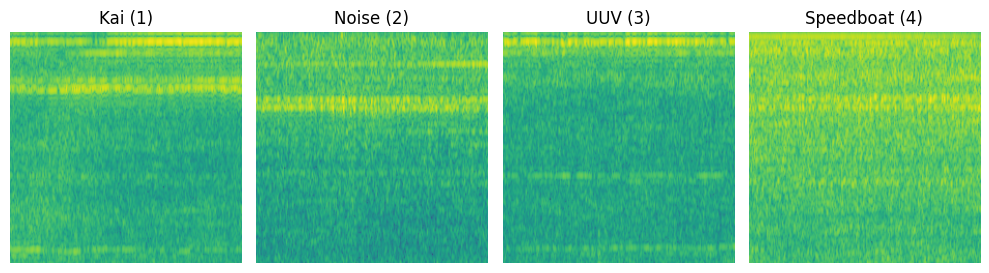

In [6]:
# VISUALIZE 1 SPECTROGRAM PER CLASS
# Map spectrogram folder names to class labels
folder_to_class = {
    'kai_spectrograms': 'Kai (1)',
    'noise_spectrograms': 'Noise (2)',
    'uuv_spectrograms': 'UUV (3)',
    'speedboat_spectrograms': 'Speedboat (4)'
}

base_path = '/content'

# Plot setup
plt.figure(figsize=(10, 4))
for idx, (folder, label) in enumerate(folder_to_class.items(), 1):
    folder_path = os.path.join(base_path, folder)
    images = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    sample = random.choice(images)
    img_path = os.path.join(folder_path, sample)
    img = Image.open(img_path)

    plt.subplot(1, 4, idx)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:
# CREATE TRAIN AND VAL FOLDERS AND SPLIT DATA
# Mapping from folder name to class index
class_map = {
    'kai_spectrograms': '1',
    'noise_spectrograms': '2',
    'uuv_spectrograms': '3',
    'speedboat_spectrograms': '4'
}
# Input folders
source_folders = list(class_map.keys())
source_root = '/content'
# Output structure
base_output = '/content/data_x'
os.makedirs(base_output, exist_ok=True)
# Create train and val subfolders
splits = ['train', 'val']
for split in splits:
    for class_id in class_map.values():
        os.makedirs(os.path.join(base_output, split, class_id), exist_ok=True)

# Set split ratios
train_ratio = 0.8
val_ratio = 0.2

# Split and copy files
for folder in source_folders:
    full_folder_path = os.path.join(source_root, folder)
    class_id = class_map[folder]
    files = [f for f in os.listdir(full_folder_path) if f.lower().endswith('.png')]
    random.shuffle(files)
    total = len(files)
    train_end = int(train_ratio * total)
    split_files = {'train': files[:train_end],'val': files[train_end:]}
    for split, split_list in split_files.items():
        for f in split_list:
            src = os.path.join(full_folder_path, f)
            dst = os.path.join(base_output, split, class_id, f)
            shutil.copy2(src, dst)
print("Split complete. Organized in /content/data_x/train and val, under class folders 1–4.")

# Check size of train and val folders for each boat type
base_dir = '/content/data_x'
splits = ['train', 'val']
class_ids = ['1', '2', '3', '4']

for split in splits:
    print(f"\n{split.upper()} SET")
    for class_id in class_ids:
        class_path = os.path.join(base_dir, split, class_id)
        file_count = len([f for f in os.listdir(class_path) if f.lower().endswith('.png')])
        print(f"  Class {class_id}: {file_count} files")

Split complete. Organized in /content/data_x/train and val, under class folders 1–4.

TRAIN SET
  Class 1: 2133 files
  Class 2: 161 files
  Class 3: 721 files
  Class 4: 2991 files

VAL SET
  Class 1: 534 files
  Class 2: 41 files
  Class 3: 181 files
  Class 4: 748 files


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm

In [9]:
# prepare data
data_dir = "/content/data_x"
# Hyperparameters
batch_size = 16
num_epochs = 10
learning_rate = 0.001
num_classes = 4  # Number of subfolders

# Image transformations
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # from ImageNet
                         std=[0.229, 0.224, 0.225])
])
vae_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [10]:
# Load dataset
vae_train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=vae_transform)
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=imagenet_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=imagenet_transform)

vae_train_loader = DataLoader(vae_train_dataset, batch_size=batch_size, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [11]:
# CNN
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Vision Transformer
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        # Load pretrained Vision Transformer Model
        self.model = models.vit_b_16(pretrained=True)
        in_features = self.model.heads.head.in_features
        self.model.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [13]:
# Initialize models, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet_model = EfficientNetModel(num_classes).to(device)
vit_model = ViTModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=learning_rate)
vit_optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 224MB/s]


In [14]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name):
    all_val_labels = []        # Store all true labels across epochs
    all_val_predictions = []   # Store all predictions across epochs
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                # Accumulate for final evaluation
                all_val_labels.extend(labels.cpu().numpy())
                all_val_predictions.extend(predicted.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        accuracy = correct / total * 100
        print(f"{model_name} Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%")

    # Final Evaluation
    print("\nOverall Evaluation")
    final_accuracy = accuracy_score(all_val_labels, all_val_predictions)
    final_precision = precision_score(all_val_labels, all_val_predictions, average='macro')
    final_recall = recall_score(all_val_labels, all_val_predictions, average='macro')
    final_confusion = confusion_matrix(all_val_labels, all_val_predictions)

    print(f"Final Accuracy: {final_accuracy * 100:.2f}%")
    print(f"Final Precision (macro): {final_precision:.4f}")
    print(f"Final Recall (macro): {final_recall:.4f}")
    print("Confusion Matrix:")
    print(final_confusion)

# Note: Training all models at the end

In [15]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=4):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.embed_dim = 16

        # Label embedding
        self.label_emb = nn.Embedding(num_classes, self.embed_dim)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3 + 1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        enc_out_dim = 256 * 14 * 14
        self.fc_mu = nn.Linear(enc_out_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_out_dim, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim + self.embed_dim, enc_out_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels):
        label_embed = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_map = label_embed[:, :1, :, :].expand(-1, 1, x.size(2), x.size(3))
        x_cond = torch.cat([x, label_map], dim=1)
        encoded = self.encoder(x_cond)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        z_cond = torch.cat([z, self.label_emb(labels)], dim=1)
        x_decoded = self.decoder_input(z_cond).view(-1, 256, 14, 14)
        x_hat = self.decoder(x_decoded)
        return x_hat, mu, logvar

    def decode(self, z, labels):
        z_cond = torch.cat([z, self.label_emb(labels)], dim=1)
        x_decoded = self.decoder_input(z_cond).view(-1, 256, 14, 14)
        return self.decoder(x_decoded)

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

model = VAE(latent_dim=128, num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in vae_train_loader:
        inputs = inputs.float().to(device)
        labels = labels.long().to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(inputs, labels)
        loss = vae_loss(recon_x, inputs, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(vae_train_loader.dataset):.4f}")

Epoch 1, Loss: 1574.2550
Epoch 2, Loss: 838.2460
Epoch 3, Loss: 675.9844
Epoch 4, Loss: 640.9711
Epoch 5, Loss: 620.2965
Epoch 6, Loss: 608.6075
Epoch 7, Loss: 601.1522
Epoch 8, Loss: 594.1636
Epoch 9, Loss: 589.6345
Epoch 10, Loss: 585.6023


In [16]:
num_per_class = 100
num_classes = 4
output_root = "/content/augmented_spectrograms"

from torchvision.utils import save_image
from torch.utils.data import ConcatDataset, DataLoader
with torch.no_grad():
    for class_id in range(num_classes):
        z = torch.randn(num_per_class, model.latent_dim).to(device)
        labels = torch.full((num_per_class,), class_id, dtype=torch.long).to(device)
        synthetic_imgs = model.decode(z, labels).cpu()

        output_folder = os.path.join(output_root, str(class_id))
        os.makedirs(output_folder, exist_ok=True)

        for i, img in enumerate(synthetic_imgs):
            save_image(img, os.path.join(output_folder, f"synth_{i}.png"))

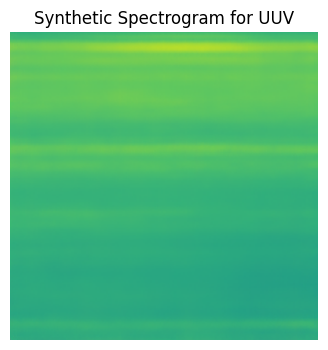

In [17]:
# Visualize a synthetic image
img_path = "/content/augmented_spectrograms/2/synth_85.png"
img = Image.open(img_path)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Synthetic Spectrogram for UUV")
plt.axis('off')
plt.show()

In [18]:
# combine with original data
vae_augmented_dataset = datasets.ImageFolder(root=output_root, transform=imagenet_transform)
vae_combined_dataset = ConcatDataset([train_dataset, vae_augmented_dataset])
vae_combined_loader = DataLoader(vae_combined_dataset, batch_size=batch_size, shuffle=True)

In [19]:
# Define Diffusion Model
class SimpleUNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_channels=64):
        super(SimpleUNetGenerator, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.middle = conv_block(base_channels * 2, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = conv_block(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = conv_block(base_channels * 2, base_channels)
        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)
        self.out = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        m = self.middle(self.pool2(e2))
        d2 = self.up2(m)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        out = self.final(d1)
        return self.out(out)

# Train
model = SimpleUNetGenerator().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for _, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        noise = torch.randn_like(real_imgs).to(device)
        output = model(noise)

        loss = loss_fn(output, real_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.5516
Epoch 2, Loss: 0.5190
Epoch 3, Loss: 0.5152
Epoch 4, Loss: 0.5127
Epoch 5, Loss: 0.5120
Epoch 6, Loss: 0.5119
Epoch 7, Loss: 0.5117
Epoch 8, Loss: 0.5117
Epoch 9, Loss: 0.5118
Epoch 10, Loss: 0.5118


In [20]:
# Generate Spectrograms
num_per_class = 100
num_classes = 4
output_root = "/content/diffusion_augmented_spectrograms"

model.eval()
with torch.no_grad():
    for class_id in range(num_classes):
        output_folder = os.path.join(output_root, str(class_id))
        os.makedirs(output_folder, exist_ok=True)

        for i in range(num_per_class):
            noise = torch.randn(1, 3, 224, 224).to(device)
            fake_img = model(noise).cpu()
            save_path = os.path.join(output_folder, f"synth_{i}.png")
            save_image(fake_img, save_path)

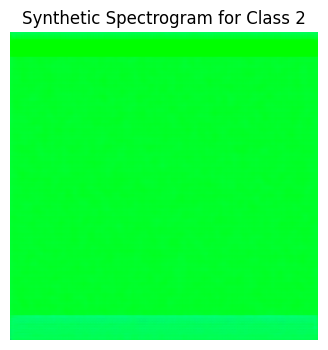

In [21]:
# Visualize a synthetic image
img_path = "/content/diffusion_augmented_spectrograms/2/synth_85.png"
img = Image.open(img_path)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Synthetic Spectrogram for Class 2")
plt.axis('off')
plt.show()

In [22]:
# combine with original data
diffusion_augmented_dataset = datasets.ImageFolder(root=output_root, transform=imagenet_transform)
diffusion_combined_dataset = ConcatDataset([train_dataset, diffusion_augmented_dataset])
diffusion_combined_loader = DataLoader(diffusion_combined_dataset, batch_size=batch_size, shuffle=True)

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=imagenet_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [23]:
# VAE AUGMENTED DATA
# Train ViT
print("ViT Model on VAE augmented data:\n")
train_model(vit_model, vit_optimizer, vae_combined_loader, val_loader, num_epochs, "ViT")
# Train EfficientNet
print("EfficientNet Model on VAE augmented data:\n")
train_model(efficientnet_model, efficientnet_optimizer, vae_combined_loader, val_loader, num_epochs, "EfficientNet")

# DIFFUSION AUGMENTED DATA
# Train ViT
print("ViT Model on Diffusion augmented data:\n")
train_model(vit_model, vit_optimizer, diffusion_combined_loader, val_loader, num_epochs, "ViT")
# Train EfficientNet
print("EfficientNet Model on Diffusion augmented data:\n")
train_model(efficientnet_model, efficientnet_optimizer, diffusion_combined_loader, val_loader, num_epochs, "EfficientNet")

# WITHOUT AUGMENTED DATA
# Train ViT
print("ViT Model on original data:\n")
train_model(vit_model, vit_optimizer, train_loader, val_loader, num_epochs, "ViT")
# Train EfficientNet
print("EfficientNet Model on original data:\n")
train_model(efficientnet_model, efficientnet_optimizer, train_loader, val_loader, num_epochs, "EfficientNet")

ViT Model on VAE augmented data:



Training ViT Epoch 1/10: 100%|██████████| 401/401 [01:04<00:00,  6.26it/s]


ViT Epoch 1/10, Train Loss: 1.1590, Val Loss: 1.1155, Val Accuracy: 49.73%


Training ViT Epoch 2/10: 100%|██████████| 401/401 [01:03<00:00,  6.32it/s]


ViT Epoch 2/10, Train Loss: 1.1223, Val Loss: 1.0948, Val Accuracy: 49.73%


...

EfficientNet Epoch 8/10, Train Loss: 0.3273, Val Loss: 0.4697, Val Accuracy: 72.87%


Training EfficientNet Epoch 9/10: 100%|██████████| 376/376 [00:27<00:00, 13.79it/s]


EfficientNet Epoch 9/10, Train Loss: 0.3242, Val Loss: 0.5105, Val Accuracy: 73.54%


Training EfficientNet Epoch 10/10: 100%|██████████| 376/376 [00:27<00:00, 13.58it/s]


EfficientNet Epoch 10/10, Train Loss: 0.3252, Val Loss: 0.5226, Val Accuracy: 74.60%

Overall Evaluation
Final Accuracy: 73.83%
Final Precision (macro): 0.8039
Final Recall (macro): 0.8147
Confusion Matrix:
[[3631    2   21 1686]
 [   1  408    0    1]
 [   4    0 1526  280]
 [1539    1  401 5539]]


# Model Comparisons
|       | Accuracy | Precision | Recall |
|-------|-------|-------|-------|
| ViT with VAE  | 51.58%  | 0.4754  | 0.3277  |
| EfficientNet with VAE  | 72.87%  | 0.7968  | 0.7991  |
| ViT with Diffusion  | 61.22%  | 0.6668  | 0.5880  |
| EfficientNet with Diffusion  | 73.96%  | 0.7926  | 0.8164  |
| ViT with Original  | 64.85%  | 0.7047  | 0.6596  |
| EfficientNet with Original  |  73.83% | 0.8039  | 0.8147 |   


# Confusion Matrix comparisons
## ViT with VAE
[[ 846,   46,   85, 4363]  
 [  37,   56,    0,  317]  
 [ 122,    0,  237, 1451]  
 [ 661,   47,  153, 6619]]  
 ## EfficientNet with VAE  
 [[2994,    6,   16, 2324]  
 [   5,  401,    0,    4]  
 [  17,    0, 1543,  250]  
 [ 985,    3,  470, 6022]]  
 ## ViT with Diffusion  
 [[2472,   20,  182, 2666]  
 [ 129,  230,    1,   50]  
 [ 221,    0, 1095,  494]  
 [1655,   27,  388, 5410]]  
  ## EfficientNet with Diffusion
  [[3554,   12,    4, 1770]  
 [   0,  410,    0,    0]  
 [   8,    0, 1535,  267]  
 [1419,   14,  423, 5624]]  
  ## ViT with Original Data
  [[2647,   31,  111, 2551]  
 [  78,  303,    0,   29]  
 [ 141,    0, 1180,  489]  
 [1476,   24,  357, 5623]]  
   ## EfficientNet with Original Data
   [[3631,    2,   21, 1686]  
 [   1,  408,    0,    1]  
 [   4,    0, 1526,  280]  
 [1539,    1,  401, 5539]]  

# Discussion  
EfficientNet consistently outperformed ViT across all datasets, showing strong accuracy and generalization even without augmentation. ViT struggled with VAE augmented data, but improved with diffusion which seemed to generate more realistic spectrograms. While EfficientNet remained stable with both VAE and diffusion, ViT only benefited from diffusion augmentation. Spectrograms worked well overall for capturing ship-specific patterns, especially when paired with CNNs. Preprocessing consistency was key, and ViT required more careful tuning. Between VAE and diffusion, diffusion clearly provided better results. These models were trained on 10 epcohs for efficiency. Increasing the epochs, while less efficient, would undoubtebly provide better results.